**Analitica de Datos**

**Pratica 02: Itroduccion al Uso de pythom en el analisis de Datos.**

Elaborado por: Avryl Salas Hernández. Grupo/Grado 9°A IEVND Matricula.230219





**1.Importamos las librerias de python para la manipulacion y analisis de datos.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mat
import seaborn as sea 

**2.Creamos un DataFrame del origen de los datos en este archivo delimitando por comas**

Este comando permite cargar en memoria cache(temporal),los datos que se van a analizar esto utilizando la liberia **PANDAS** que nos permite la manipulacion de datos.

In [2]:
df=pd.read_csv('UberDataset.csv')


**3.Imprimimos en pantalla los datos cargados para verificar la carga correcta.**

**Importante:** La impresion de los DATAFRAME no da contexto importante como el numero de columnas y en caso de datos **CUANTITATIVOS** una suma del total de la columna, en caso de los datos **CUALITATIVOS** nos colocara en texto NaN (Not as Number) por defecto por no se pueden sumar

In [3]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**4.Leer los datos de una columna especifica**
El uso **['COLUMA']** nos permite poder acceder a los datos de la columna del dataframe, mostrando los 5 y 5 ultimos el total de registros y el tipo de datos cabe mencionar que este comando 

In [4]:
df['PURPOSE']

0        Meal/Entertain
1                   NaN
2       Errand/Supplies
3               Meeting
4        Customer Visit
             ...       
1151     Temporary Site
1152            Meeting
1153     Temporary Site
1154     Temporary Site
1155                NaN
Name: PURPOSE, Length: 1156, dtype: object

**5.Manipulamos los datos cargados para obtener el total de cada valor registrado en la columna**

El metodo value_counts() es una funcion preprogramada de python que nos permite agrupar por sus valores y obtener el total de cada valor detectado.

In [5]:
df['PURPOSE'].value_counts()

PURPOSE
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Charity ($)          1
Commute              1
Name: count, dtype: int64

**6.Aplicamos la misma funcion con otra columna**

En este caso vemos que tipos de viajes hizo el conductor, resultados **"Bussiness"** (Negocios) o **"Personal"** (Asuntos Personales)

In [6]:
df['CATEGORY'].value_counts()

CATEGORY
Business    1078
Personal      77
Name: count, dtype: int64

**7.Limpiamos el dataframe de los viajes que no tienen un destino localizable**

Para este analisis es importante limpiar los datos de la muestra que nos sirven para nuestro analisis empezamos por eliminar los registros (Filas)
de aquello viajes que no registraron un destino localizable. Para ello utilizamos el comando logico de no igualdad (!=) para filtrar el dataframe, esto nos arrojara un resultado de booleando "TRUE" para lo que tienen un destino localizable y "False" para los que no.

In [7]:
df['STOP']!='Unknown Location'

0        True
1        True
2        True
3        True
4        True
        ...  
1151    False
1152    False
1153     True
1154     True
1155     True
Name: STOP, Length: 1156, dtype: bool

**8.Eliminamos del DataFrame los registros que contengan falso**

In [8]:
df=df[df['STOP']!='Unknown Location']
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


9. **Sobreescribimos del dataframe (df)**

Para eliminar de nuestrp analisis, esdecir que el documento de origen de los datos (cvs) sigue sin cambios asignamos el resultado del filtrado

In [9]:
df=df[df['START']!='Unknown Location']


10. **Volvemos a imprimir el dataframe**

En este resultado podemos observar que el nuevo dataframe cuenta solo con **1007** filas a diferencia del original que tenia **1156**, es decir se eliminaron **149** registros que no tenian un destino localizable.

In [10]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


11. **Repetimos el proceso de limpieza ahora los viajes que no tienen un origen localizable (START)**

En este caso realizamos toda la limpieza en una sola operacion, obteniendo una actualizacion del df que ocuparemos para analisis de datos reduciendo de **1007** a **945** registros, incluyendo que hay **62** viajes que tuviron un destino(STOP) pero no un origen (START)

In [11]:
df=df[df['START']!='Unknown Location']
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


12. **Conceptos de Repaso**

*12.1 Funciones o Métodos en Python:*
Una función o métodos es un bloqueo de codigo reutilizable que realiza una tarea especifica. Sirve para evitar repetir instrucciones y organizar mejor los programas. 

En el lenguaje de Programación de Python las funciones son declaradas con la palabra reservada **def**, y para ejecutarlas basta con escribir el nombre que se le asigno a la misma, el uso de () es para emviar los datos dde entrada en caso de que sean necesarios.

Definición:

In [12]:
def saludar():
    print ("Hola, Bienvenid@ a Python para el Análisis de Datos")

*Llamado:*

In [13]:
saludar()

Hola, Bienvenid@ a Python para el Análisis de Datos


12.2 *Funciones que reciben una parámatro o datos de entrada en algunas ocasiones en necesario enviar datos para la ejecución del método, para ello debemos declaralo en la defnición de la función entre()* 

*Definición:*

In [14]:
def saludar_nombre(nombre):
    return f"Hola, {nombre} Bienvenid@ a Python para el Análisis de Datos"

*Llamado:*

In [15]:
saludar_nombre("Avryl")

'Hola, Avryl Bienvenid@ a Python para el Análisis de Datos'

In [16]:
saludar_nombre("Hugo")

'Hola, Hugo Bienvenid@ a Python para el Análisis de Datos'

*12.3 Funciones que mandan llamar otras funciones y que regresan el resultado de un procesaiento*, en este caso utilizaremos una funcion predefinida en python denomina replace que nos permite sustituir letras en una cadena texto.

*Definicion:*

In [17]:
def sustituir_vocales(texto):
        texto = texto.replace("A","4")
        texto = texto.replace("a","4")
    
        texto = texto.replace("E","3")
        texto = texto.replace("e","3")

        texto = texto.replace("I","1")
        texto = texto.replace("i","1")
    
        texto = texto.replace("O","0")
        texto = texto.replace("o","0")
    
        texto = texto.replace("U","∪")
        texto = texto.replace("u","∪")

        return texto

*Llamado:*

In [18]:
print(sustituir_vocales(saludar_nombre("Avryl")))

H0l4, 4vryl B13nv3n1d@ 4 Pyth0n p4r4 3l 4nál1s1s d3 D4t0s


13. **Limpieza de letras ilegibles**

    Ejecutamos el proceso de sustitucion de las letras legibles ( para este caso de estudio solo hay letras a con tilde que se cargaron con un ?, y se limpia con una "a" para mejor compresión del analisis. 

In [19]:
df['START'] = df['START'].astype(str).str.replace('?','a')
df['STOP'] = df['STOP'].astype(str).str.replace('?','a')
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


14. **Rellenar datos vacios por un valor generico asignado**

Durante el proceso de Limpieza y Transformación de los datos, existe la posibilidad de corregir datos que no se encuentren registrados, para este caso usaremos una funcion de **PANDAS** llamada *fillna*, (sirve para rellenar los datos no disponibles (not avalaible) en este caso serán sustituido por la palabra *Others*, en el dataframe original por eso se activa **inplace**=**True**

In [20]:
df['PURPOSE'].fillna('Others', inplace=True)
df

C:\Users\PC-04\AppData\Local\Temp\ipykernel_4648\2042178618.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PURPOSE'].fillna('Others', inplace=True)


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [21]:
def value(val):
    val=str(val)
    return val.replace('?','a')
df['START']=df['START'].apply(value)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


15. **Medidas de Tendencia Central**

Una vez terminada la fase de limpieza de datos, comenzamos con la Estadítica Básica, en este caso consultaremos las medidas de tendencia central siendo: Total,Media, Cuartiles y Desviación Estándar, Máximo y Mínimo.

Utilizando en método **describe** de nuestro dataframe, se buscaran todos los datos  cuantitativos (Numericos) de la muestra y realizara el calculo de estos valores, para este caso en especifico solo tenemos la columna **MILES**, la cual hace referencia al total de Millas Terrestres (1.609 Km) recorridas por el conductor en un servicio de viaje a traves de UBER.

In [22]:
df.describe()

,MILES
count,945.000000
mean,22.809841
std,397.276813
min,0.500000
25%,2.600000
50%,5.300000
75%,9.900000
max,12204.700000


Para el caso de Mediana y Moda, estas debe ser calculadas por separado a traves de las funciones .mode y .median

In [23]:
print(df['MILES'].mode())

0    9.9
Name: MILES, dtype: float64


In [24]:
print(df['MILES'].median())

5.3


En **CONCLUSIÓN** este dataframe nos permite analizar una pequeña muestra de **945** Viajes realizados a travbes de la aplicacion de UBER, determinando que la distancia mínima registrada es de .5 Millas y las Máxima de **12204.7** millas, con un promedio de **22.8** millas, siendo la distancia más repetida de **9.9** millas y la mediana de **5.3** millas.

16.**Limpieza de Datos: Segmentar la fecha del viaje, ignorando la HH:MM:SS**

In [25]:
def val(value):
    value=str(value)
    value=value.split()
    return value[0].replace('-','/')
df['START_DATE']=df['START_DATE'].apply(val)

def val(value):
    value=str(value)
    value=value.split()
    return value[0].replace('-','/')
df['END_DATE']=df['END_DATE'].apply(val)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016,01/06/2016,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016,12/31/2016,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016,12/31/2016,Business,Gampaha,Ilukwatta,48.2,Temporary Site


17.**Eliminamos la ultima fila de totales**

La ultima fila no es necesaria para la graficacion dado que podria generar error en la presentacion de datos, por ello la eliminamos del DataFrame usando el comando drop y el numero de la posicion de la fila a eliminar encerrada entre corchetes[].

In [26]:
df.drop([1155],inplace=True)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016,01/06/2016,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016,12/31/2016,Business,Katunayake,Gampaha,6.4,Temporary Site


18. **Eliminar los datos de los cuartiles menores**

**quantile()** es una función de pandas que divide los datos en porcentajes.

*El código busca valores altos y bajos en la columna MILES.*

a) guarda el valor del 95% → **los kilómetros más altos.**

b) guarda el valor del 5% → **los kilómetros más bajos.**

df3 guarda únicamente las filas donde MILES es mayor al percentil 95, es decir, **los valores más altos del dataset.**

*¿Para qué se hace esto?*

Detectar outliers,analizar valores extremos,limpiar datos,estudiar vehículos con mucho kilometraje y eliminar ruido estadístico.


In [27]:
a=df['MILES'].quantile(0.95)
b=df['MILES'].quantile(0.05)
df3=df[df['MILES']>b]
df3=df[df['MILES']<a]
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain
...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting


19. **Calculo de la Desviacion Estándar**

    Para entender que tan variables o dispersas son las distancias de los viajes.

In [28]:
df3['STD']=df.MILES.std()
df3

C:\Users\PC-04\AppData\Local\Temp\ipykernel_4648\672307851.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['STD']=df.MILES.std()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Others,21.472805
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805
...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting,21.472805
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit,21.472805
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting,21.472805


20. **Estimar el valor de Z-Score o Puntuacion Z**

Con la finalidad de estimar la dispercion de los datos, es decir que tan variadas o diferentes son, utilizamos esta formula estadistica para poder continuar con el analisis EDA(Exploratory Data Analisys).

In [29]:
df3['Z']=(df.MILES-df.MILES.mean())/df.MILES.std()
df3

C:\Users\PC-04\AppData\Local\Temp\ipykernel_4648\2738585948.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['Z']=(df.MILES-df.MILES.mean())/df.MILES.std()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD,Z
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805,-0.223785
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Others,21.472805,-0.228442
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805,-0.237756
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805,-0.242413
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805,-0.261042
...,...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805,-0.247070
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting,21.472805,-0.247070
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit,21.472805,-0.424039
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting,21.472805,-0.428696


21. **Filtramos aquello que no esten en el rango de -1 y 1**

In [32]:
df["MILES"].describe()

count    944.000000
mean       9.905297
std       21.472805
min        0.500000
25%        2.600000
50%        5.300000
75%        9.900000
max      310.300000
Name: MILES, dtype: float64

In [33]:
df3["MILES"].describe()

count    896.000000
mean       6.344196
std        4.849186
min        0.500000
25%        2.500000
50%        4.900000
75%        9.025000
max       25.600000
Name: MILES, dtype: float64

In [30]:
df3=df3[(df3.Z>-1) & (df3.Z<1)]
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD,Z
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805,-0.223785
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Others,21.472805,-0.228442
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805,-0.237756
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805,-0.242413
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805,-0.261042
...,...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805,-0.247070
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting,21.472805,-0.247070
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit,21.472805,-0.424039
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting,21.472805,-0.428696


22. **Graficacion basica para un analisis mas visual y simplicado**

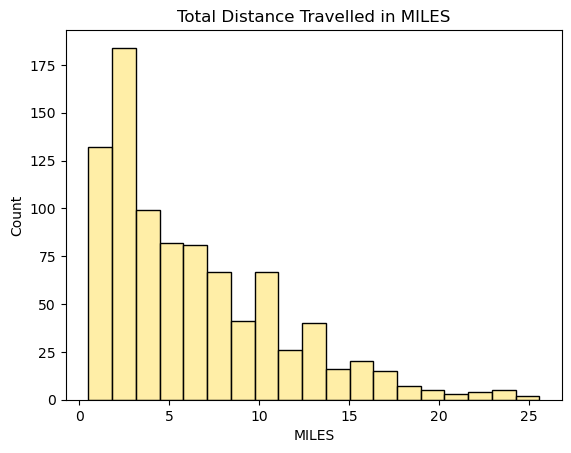

In [40]:
mat.title('Total Distance Travelled in MILES')
sea.histplot(df3.MILES,color='#FFE98A')
mat.show()

23. **Gradico de clasificación de Viajes por Categoria**

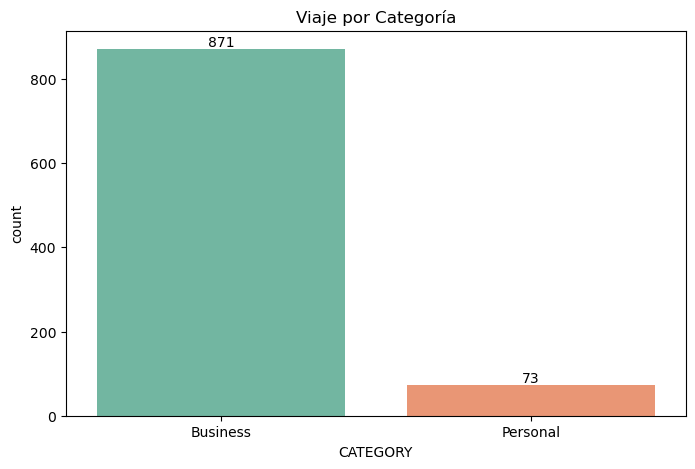

In [43]:
fig, ax = mat.subplots(figsize=(8,5))

grafica = sea.countplot(
    data=df,
    x='CATEGORY',
    hue='CATEGORY',
    palette='Set2',
    legend=False,
    ax=ax
)

# Título
ax.set_title('Viaje por Categoría')

# Agregar etiquetas con totales
for container in ax.containers:
    ax.bar_label(container)
    
mat.show()

24. **Gráfica de Viajes por proposito (PURPOSE)**

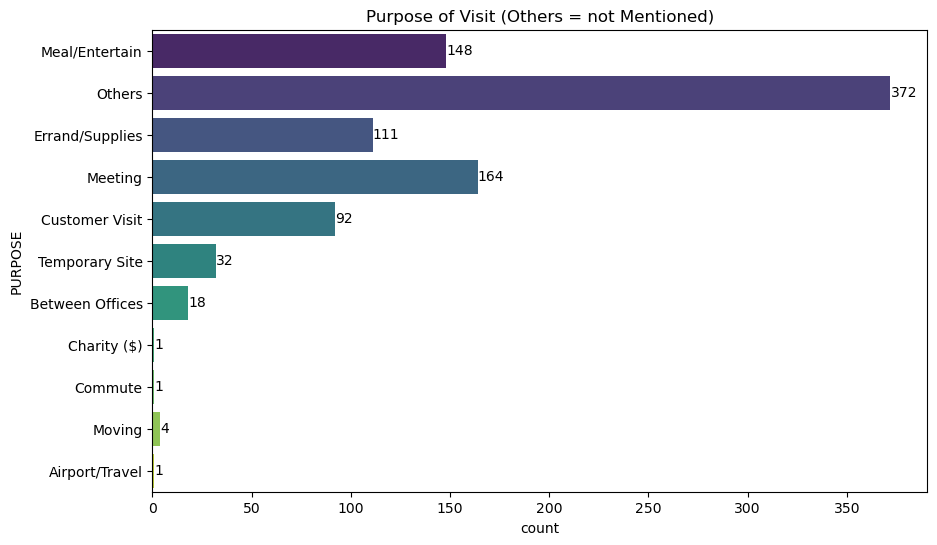

In [45]:
fig, ax = mat.subplots(figsize=(10,6))

grafica = sea.countplot(
    data=df,
    y='PURPOSE',
    hue='PURPOSE',
    dodge=False,
    palette='viridis',
    legend=False
)

# Título
ax.set_title('Purpose of Visit (Others = not Mentioned)')

# Agregar totales
for container in ax.containers:
    ax.bar_label(container)
    
mat.show()

25. **Gráfico de lugar de Abordaje (START)**

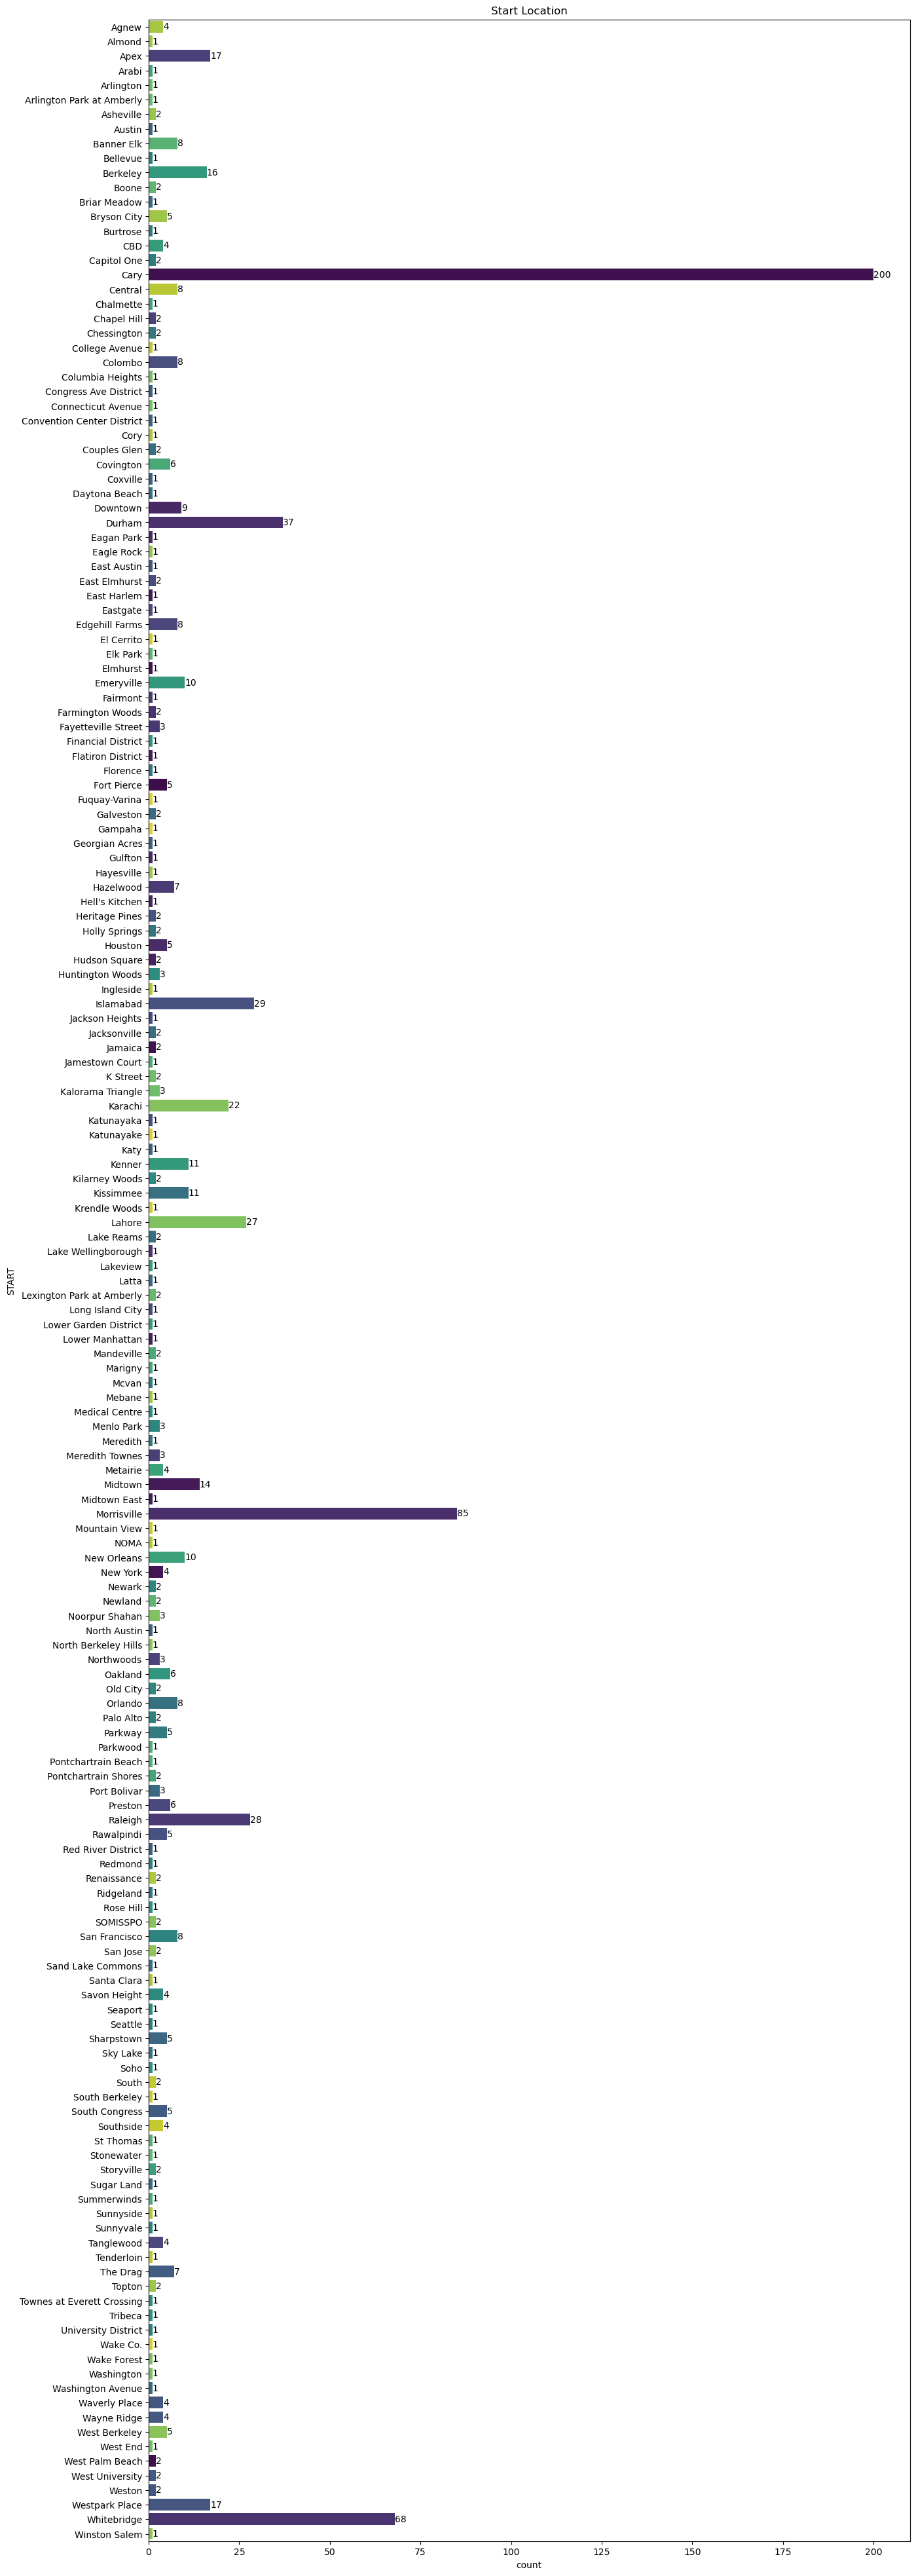

In [47]:
fig, ax = mat.subplots(figsize=(15,50))


# Ordenar alfabeticamente
orden = sorted(df['START'].dropna().unique())

grafica = sea.countplot(
    data=df,
    y='START',
    order=orden,
    hue='START',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax
)

# Título
ax.set_title('Start Location')

# Agregar totales
for container in ax.containers:
    ax.bar_label(container)
    
mat.show()

26. **Grafica de lugar de llegada(STOP)**

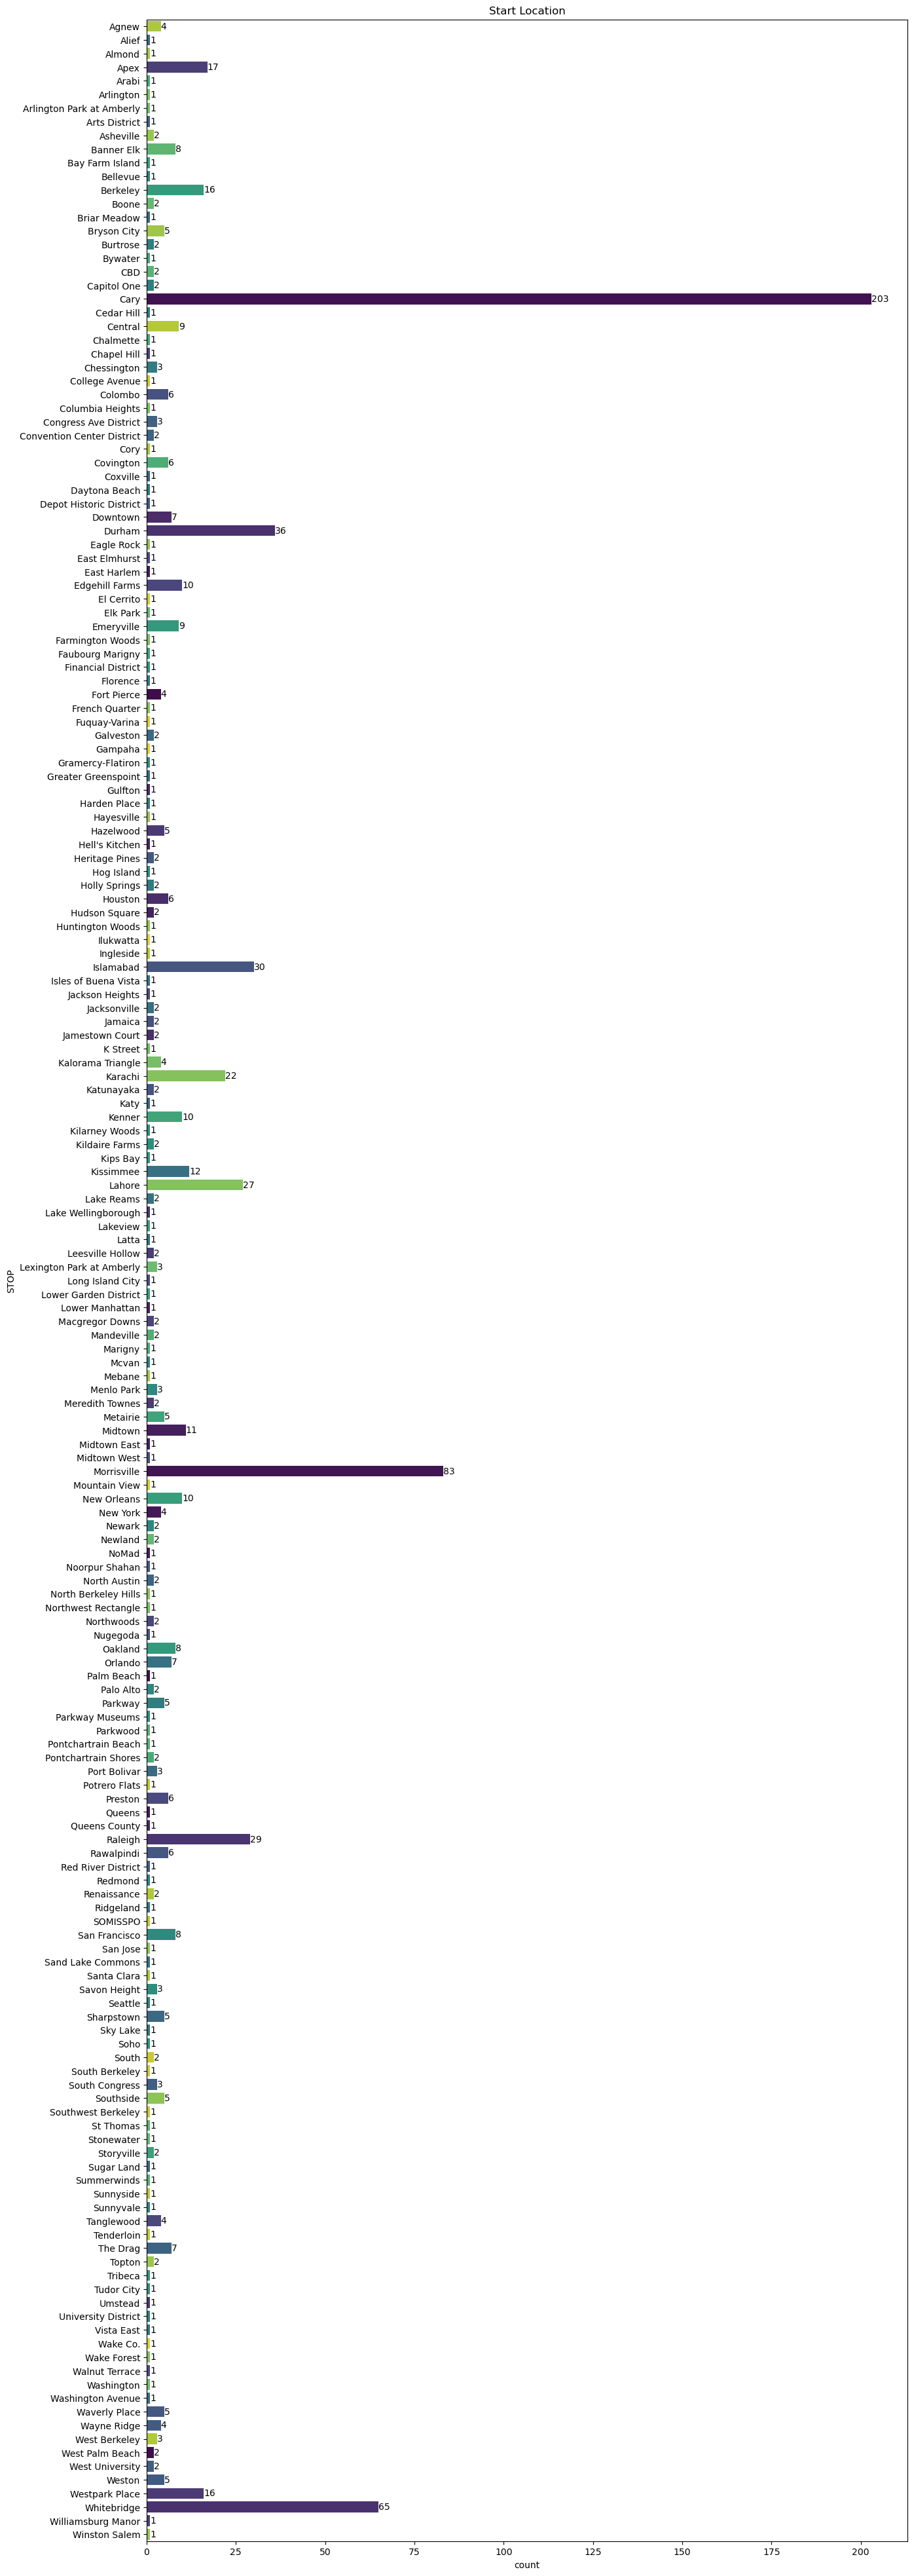

In [57]:
fig, ax = mat.subplots(figsize=(15,50))

# Ordenar alfabeticamente
orden = sorted(df['STOP'].dropna().unique())

grafica = sea.countplot(
    data=df,
    y='STOP',
    order=orden,
    hue='STOP',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax
)

# Título
ax.set_title('Start Location')

# Agregar totales
for container in ax.containers:
    ax.bar_label(container)
    
mat.show()

**Conclusión**

En conclusión, esta práctica permitió aplicar correctamente los fundamentos de la analítica de datos mediante el uso de Python en Anaconda, utilizando herramientas como Pandas, NumPy, Matplotlib y Seaborn para el procesamiento y análisis de información. Durante el desarrollo se realizaron procesos de limpieza y preparación de datos, eliminando registros incorrectos, corrigiendo caracteres y rellenando valores nulos para obtener un conjunto de datos más confiable.
Además, mediante el uso de medidas estadísticas y visualizaciones gráficas, fue posible identificar patrones importantes en los viajes analizados, como las categorías más frecuentes, los propósitos predominantes y la distribución de distancias recorridas. 

También se aplicaron métodos para detectar y reducir el impacto de valores atípicos, mejorando la precisión de los resultados obtenidos.
Finalmente, esta práctica demuestra que la analítica de datos no solo consiste en programar, sino en transformar datos en información útil para interpretar comportamientos y apoyar la toma de decisiones. Asimismo, permitió fortalecer habilidades esenciales en análisis estadístico, manejo de datos y visualización de información, competencias fundamentales dentro del área de ciencia y analítica de datos.
